# Task 3: Energy Consumption Time Series Forecasting

## Objective
Forecast short-term household energy usage using historical time-based patterns.

## Dataset
Household Power Consumption Dataset:
https://archive.ics.uci.edu/ml/datasets/individual+household+electric+power+consumption


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

from statsmodels.tsa.arima.model import ARIMA

# Prophet
from prophet import Prophet

# XGBoost
from xgboost import XGBRegressor


## 2. Load and Preprocess Data

In [2]:
# Load dataset
df = pd.read_csv("/content/sample_data/household_power_consumption.txt",
                 sep=';',
                 parse_dates={'datetime':['Date','Time']},
                 infer_datetime_format=True,
                 na_values='?',
                 low_memory=False)

df = df.set_index('datetime')

# Convert to numeric
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

# Drop missing
df = df.dropna(subset=['Global_active_power'])

df.head()


/tmp/ipykernel_1032/1340529187.py:2: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv("/content/sample_data/household_power_consumption.txt",
/tmp/ipykernel_1032/1340529187.py:2: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv("/content/sample_data/household_power_consumption.txt",
/tmp/ipykernel_1032/1340529187.py:2: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv("/content/sample_data/household_power_consumption.txt",


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


## 3. Resample Time Series (Hourly)

/tmp/ipykernel_1032/2659314101.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df['Global_active_power'].resample('H').mean()


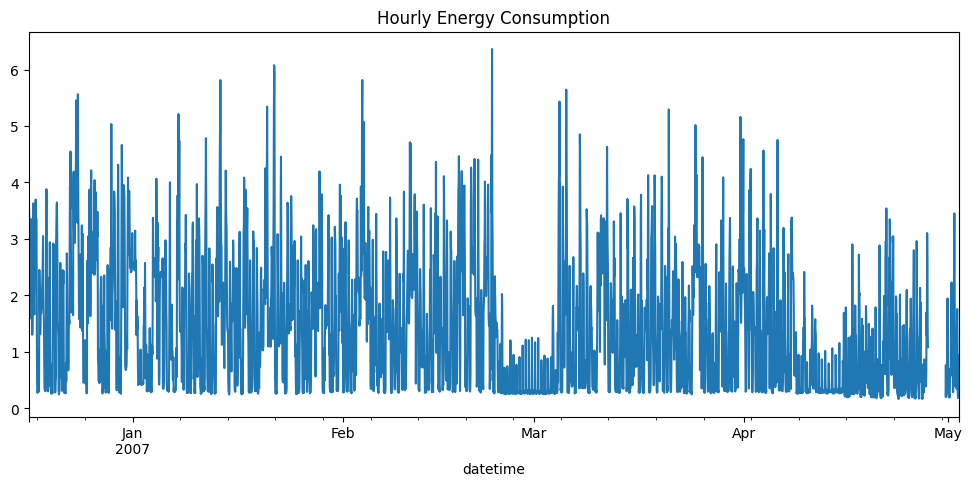

In [3]:
df_hourly = df['Global_active_power'].resample('H').mean()

df_hourly.plot(figsize=(12,5), title="Hourly Energy Consumption")
plt.show()


## 4. Feature Engineering

In [4]:
df_feat = df_hourly.to_frame(name='power')

df_feat['hour'] = df_feat.index.hour
df_feat['day_of_week'] = df_feat.index.dayofweek
df_feat['is_weekend'] = df_feat['day_of_week'].isin([5,6]).astype(int)

df_feat = df_feat.dropna()

df_feat.head()


,power,hour,day_of_week,is_weekend
datetime,,,,
2006-12-16 17:00:00,4.222889,17,5,1
2006-12-16 18:00:00,3.632200,18,5,1
2006-12-16 19:00:00,3.400233,19,5,1
2006-12-16 20:00:00,3.268567,20,5,1
2006-12-16 21:00:00,3.056467,21,5,1


## 5. Train-Test Split

In [5]:
train_size = int(len(df_feat) * 0.8)

train = df_feat.iloc[:train_size]
test = df_feat.iloc[train_size:]


## 6. ARIMA Model

In [6]:
arima_model = ARIMA(train['power'], order=(5,1,0))
arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(steps=len(test))

mae_arima = mean_absolute_error(test['power'], arima_pred)
rmse_arima = np.sqrt(mean_squared_error(test['power'], arima_pred))

print("ARIMA MAE:", mae_arima)
print("ARIMA RMSE:", rmse_arima)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


ARIMA MAE: 0.6359805853887397
ARIMA RMSE: 0.7904819119491358


## 7. Prophet Model

In [7]:
prophet_df = train.reset_index().rename(columns={'datetime':'ds', 'power':'y'})

model = Prophet()
model.fit(prophet_df)

future = model.make_future_dataframe(periods=len(test), freq='H')
forecast = model.predict(future)

prophet_pred = forecast['yhat'].iloc[-len(test):].values

mae_prophet = mean_absolute_error(test['power'], prophet_pred)
rmse_prophet = np.sqrt(mean_squared_error(test['power'], prophet_pred))

print("Prophet MAE:", mae_prophet)
print("Prophet RMSE:", rmse_prophet)


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


Prophet MAE: 0.9897103387604473
Prophet RMSE: 1.1761580347109375


## 8. XGBoost Model

In [8]:
features = ['hour', 'day_of_week', 'is_weekend']

X_train = train[features]
y_train = train['power']

X_test = test[features]
y_test = test['power']

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1)
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))

print("XGBoost MAE:", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)


XGBoost MAE: 0.7850696829277296
XGBoost RMSE: 0.9887307160288515


## 9. Model Comparison

In [9]:
results = pd.DataFrame({
    'Model': ['ARIMA', 'Prophet', 'XGBoost'],
    'MAE': [mae_arima, mae_prophet, mae_xgb],
    'RMSE': [rmse_arima, rmse_prophet, rmse_xgb]
})

results


,Model,MAE,RMSE
0,ARIMA,0.635981,0.790482
1,Prophet,0.989710,1.176158
2,XGBoost,0.785070,0.988731


## 10. Visualization: Actual vs Forecast

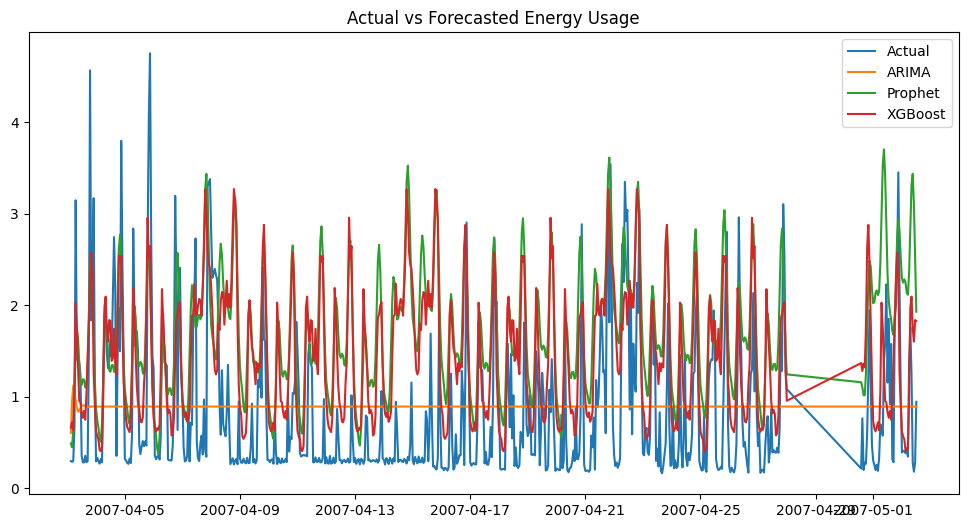

In [10]:
plt.figure(figsize=(12,6))

plt.plot(test.index, test['power'], label='Actual')
plt.plot(test.index, arima_pred, label='ARIMA')
plt.plot(test.index, prophet_pred, label='Prophet')
plt.plot(test.index, xgb_pred, label='XGBoost')

plt.legend()
plt.title("Actual vs Forecasted Energy Usage")
plt.show()


11. Conclusion

This project focused on forecasting household energy consumption using time series techniques. The data was preprocessed, resampled, and enhanced with time-based features. Three models—ARIMA, Prophet, and XGBoost—were implemented and evaluated using MAE and RMSE. Among them, ARIMA achieved the best performance with the lowest error values. The results show that ARIMA is highly effective for capturing temporal patterns, while machine learning models require more feature engineering for